In [1]:
import schemdraw
import schemdraw.elements as elm
from schemdraw.segments import SegmentPoly
import math

from PIL import Image
import matplotlib.pyplot as plt

import os

In [2]:
def next_name(folder_path):
    # Listar todos os arquivos na pasta que terminam com .png
    png_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
    
    if not png_files:
        # Se não houver arquivos JPG, o primeiro nome será "1.png"
        return "1.png"
    
    # Remover a extensão e converter para inteiro para ordenar
    numbers = [int(os.path.splitext(f)[0]) for f in png_files]
    
    # Encontrar o maior número e adicionar 1
    next_number = max(numbers) + 1
    
    # Retornar o próximo nome de arquivo
    return f"{next_number}.png"

In [3]:
class Meter(elm.Element):
    def __init__(self, radius=1, length=2, symbol='?', arrow_angle=45, **kwargs):
        super().__init__(**kwargs)
        
        radius *= 0.5
        diameter = 2*radius

        if(diameter > length):
            length = length*diameter
        
        wire = ((length-2*radius)/2)

        self.anchors['start'] = (0, 0)
        self.anchors['end'] = (length, 0)

        if(wire < 0): wire = 0
        self.segments.append(elm.elements.Segment([(0, 0), (wire, 0)]))
        self.segments.append(elm.elements.SegmentCircle((wire+radius, 0), radius))  # Desenha o círculo do amperímetro
        self.segments.append(elm.elements.Segment([(wire+2*radius, 0), (length, 0)]))

        arrow_diameter = .7
        
        head_length=0.175*diameter

        head_width = 0.25*diameter
        
        arrow_angle_radians = math.radians(arrow_angle)

        head_tip = ((length/2)+(arrow_diameter/2)*diameter*math.cos(arrow_angle_radians), 
                    (arrow_diameter/2)*diameter*math.sin(arrow_angle_radians)) # Extremidade da ponta da seta
        
        body_tip = ((length/2)-(arrow_diameter/2)*diameter*math.cos(arrow_angle_radians), 
                    -(arrow_diameter/2)*diameter*math.sin(arrow_angle_radians)) # Extremidade do corpo da seta
        
        self.segments.append(elm.elements.Segment([body_tip, head_tip], arrow='->', arrowwidth=head_width, arrowlength=head_length))

        alpha_angle_radians = math.radians(45-arrow_angle)
        font_size = int(28*radius)

        if 0 <= arrow_angle <= 90 or 270 <= arrow_angle <= 360:
            symbol_coord = symbol_coord = (((body_tip[0] if body_tip[0] < head_tip[0] else head_tip[0]) + arrow_diameter*radius*math.cos(alpha_angle_radians)),
                            (body_tip[1] if body_tip[1] < head_tip[1] else head_tip[1]))
        else:
            symbol_coord = (((body_tip[0] if body_tip[0] > head_tip[0] else head_tip[0]) + arrow_diameter*radius*math.cos(alpha_angle_radians)),
                            -(body_tip[1] if body_tip[1] < head_tip[1] else head_tip[1]))

        self.segments.append(elm.elements.SegmentText(symbol_coord, symbol, fontsize=font_size))  # Adiciona o texto "A" no centro do círculo

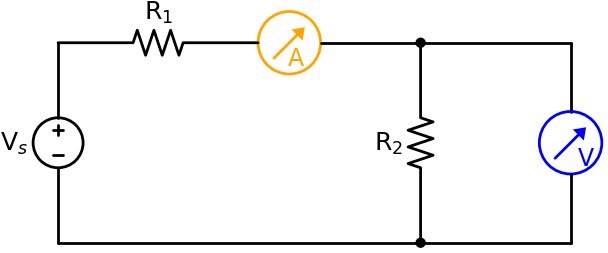

In [4]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)
    
    v1 = elm.SourceV().up().label('V$_s$', loc='top')
    r1 = elm.Resistor().right().label('R$_1$', loc='top')
    amp = Meter(length=1, radius=1.25, symbol='A', arrow_angle=45).right().color('orange')
    l1 = elm.Line().right().length(2).at(amp.end)
    d1 = elm.Dot()
    
    d.push()
    r2 = elm.Resistor().down().label('R$_2$', loc='top')
    d2 = elm.Dot()
    d.pop()

    l2 = elm.Line().right().length(3)
    volt = Meter(length=4, radius=1.25, symbol='V', arrow_angle=135).down().zorder(0)
    volt.segments[1].color = 'blue'
    volt.segments[3].color = 'blue'
    volt.segments[4].color = 'blue'
    l5 = elm.Line().left().at(volt.end).tox(v1.start)
    

    #d.save(next_name("./"), dpi=600, transparent=True)

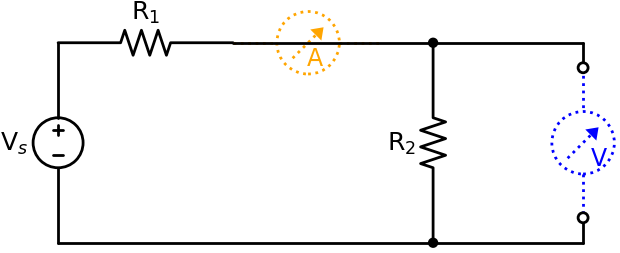

In [5]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)
    
    v1 = elm.SourceV().up().label('V$_s$', loc='top')
    r1 = elm.Resistor().right().label('R$_1$', loc='top').length(3.5)
    amp = Meter(length=3, radius=1.25, symbol='A').right().color('orange').linestyle(':')

    l1 = elm.Line().right().length(4).at(amp.start)
    d1 = elm.Dot()
    
    d.push()
    r2 = elm.Resistor().down().label('R$_2$', loc='top')
    d2 = elm.Dot()
    d.pop()

    l2 = elm.Line().right().length(3)
    l3 = elm.Line().down().length(.5)
    d3 = elm.Dot(open=True, radius=.1)
    volt = Meter(length=3, radius=1.25, symbol='V', arrow_angle=135).down().color('blue').linestyle(':')
    d3 = elm.Dot(open=True, radius=.1).at(volt.end)
    l4 = elm.Line().down().length(.5)
    l5 = elm.Line().left().tox(v1.start)
    
    #d.save(next_name("./"), dpi=600, transparent=True)

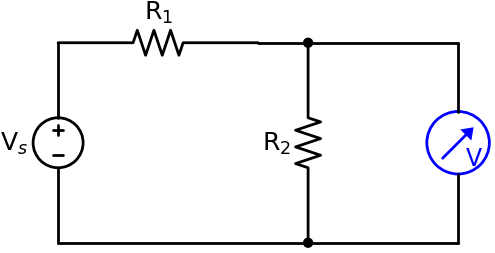

In [6]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)
    
    v1 = elm.SourceV().up().label('V$_s$', loc='top')
    r1 = elm.Resistor().right().label('R$_1$', loc='top')
    l1 = elm.Line().right().length(1)
    d1 = elm.Dot()
    
    d.push()
    r2 = elm.Resistor().down().label('R$_2$', loc='top')
    d2 = elm.Dot()
    d.pop()

    l2 = elm.Line().right().length(3)
    volt = Meter(length=4, radius=1.25, symbol='V', arrow_angle=135).down()
    volt.segments[1].color = 'blue'
    volt.segments[3].color = 'blue'
    volt.segments[4].color = 'blue'
    l5 = elm.Line().left().at(volt.end).tox(v1.start)
    

    #d.save(next_name("./"), dpi=600, transparent=True)

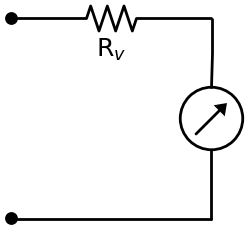

In [7]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)
    
    d1 = elm.Dot(radius=.1)
    r1 = elm.Resistor().right().label('R$_v$', loc='bot')
    l3 = elm.Line().down().length(1.375)
    volt = Meter(length=1, radius=1.25, symbol='', arrow_angle=135).down()
    l4 = elm.Line().down().length(1.375).at(volt.end)
    l5 = elm.Line().left().tox(v1.start)
    d2 = elm.Dot(radius=.1)

    #d.save(next_name("./"), dpi=600, transparent=True)

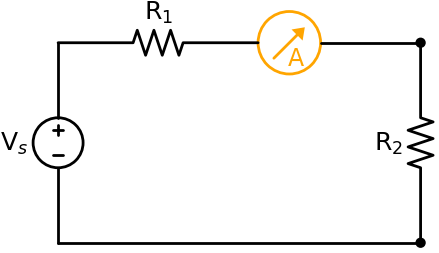

In [8]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)
    
    v1 = elm.SourceV().up().label('V$_s$', loc='top')
    r1 = elm.Resistor().right().label('R$_1$', loc='top')
    amp = Meter(length=1, radius=1.25, symbol='A', arrow_angle=45).right().color('orange')
    l1 = elm.Line().right().length(2).at(amp.end)
    d1 = elm.Dot()
    
    r2 = elm.Resistor().down().label('R$_2$', loc='top')
    d2 = elm.Dot()

    l2 = elm.Line().tox(v1.start)
    

    #d.save(next_name("./"), dpi=600, transparent=True)

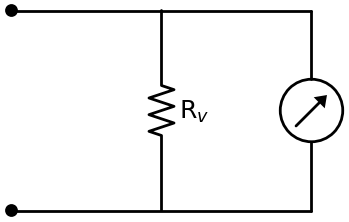

In [9]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)
    
    d1 = elm.Dot(radius=.1)
    l1 = elm.Line().right(length=3)
    d.push()
    r1 = elm.Resistor().down().label('R$_v$', loc='bot')
    d.pop()
    l2 = elm.Line().right().length(3)
    l3 = elm.Line().down().length(1.375)
    amp = Meter(length=1, radius=1.25, symbol='', arrow_angle=135).down()
    l4 = elm.Line().down().length(1.375).at(amp.end)
    l5 = elm.Line().left().tox(d1.start)
    d2 = elm.Dot(radius=.1)

    #d.save(next_name("./"), dpi=600, transparent=True)

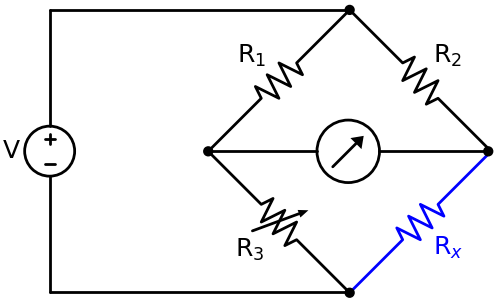

In [10]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)


    v1 = elm.SourceV().up().label('V', loc='top').length(5.65)
    l1 = elm.Line().right().length(6)
    d1 = elm.Dot()
    d.push()
    r1 = elm.Resistor().label('R$_1$', loc='top').theta(-135)
    r3 = elm.ResistorVar().label('R$_3$', loc='bot', ofst=[0, .25]).theta(-45)
    d.pop()
    r2 = elm.Resistor().label('R$_2$', loc='top').theta(-45)
    r4 = elm.Resistor().label('R$_x$', loc='bot').theta(-135).color('blue')
    d2 = elm.Dot()
    l2 = elm.Line().right().length(6).at(v1.start)
    
    d3 = elm.Dot().at(r1.end)
    amp = Meter(length=5.6, radius=1.25, symbol='', arrow_angle=45)
    d4 = elm.Dot().at(amp.end)
    #d.save(next_name("./"), dpi=600, transparent=True)

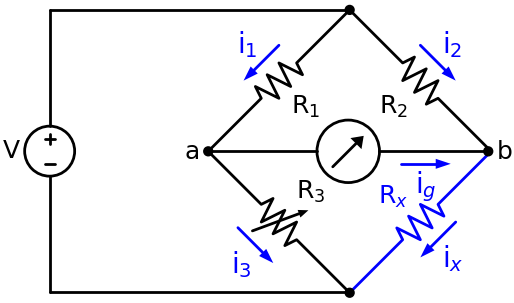

In [11]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)


    v1 = elm.SourceV().up().label('V', loc='top').length(5.65)
    l1 = elm.Line().right().length(6)
    d1 = elm.Dot()
    d.push()
    r1 = elm.Resistor().label('R$_1$', loc='bot').theta(-135)
    r3 = elm.ResistorVar().label('R$_3$', loc='top', ofst=[0, -.25]).theta(-45)
    d.pop()
    r2 = elm.Resistor().label('R$_2$', loc='bot').theta(-45)
    r4 = elm.Resistor().label('R$_x$', loc='top').theta(-135).color('blue')
    d2 = elm.Dot()
    l2 = elm.Line().right().length(6).at(v1.start)
    
    d3 = elm.Dot().at(r1.end).label('a', loc='left')
    amp = Meter(length=5.6, radius=1.25, symbol='', arrow_angle=45)
    d4 = elm.Dot().at(amp.end).label('b', loc='right')

    A1 = elm.CurrentLabel(top=False, ofst=.25, length=1, reverse=False).at(r1).label('i$_1$', loc='top', fontsize=20).color('blue')
    A2 = elm.CurrentLabel(top=True, ofst=.25, length=1, reverse=False).at(r2).label('i$_2$', loc='top', fontsize=20).color('blue')
    A3 = elm.CurrentLabel(top=False, ofst=0, length=1, reverse=False).at(r3).label('i$_3$', loc='bot', fontsize=20).color('blue')
    A4 = elm.CurrentLabel(top=True, ofst=.25, length=1, reverse=False).at(r4).label('i$_x$', loc='bot', fontsize=20).color('blue')
    A5 = elm.CurrentLabel(top=True, ofst=0, length=1, reverse=False).at((amp.end[0]-1.25, amp.end[1]-.25)).label('i$_g$', loc='bot', fontsize=20).color('blue')
    #d.save(next_name("./"), dpi=600, transparent=True)

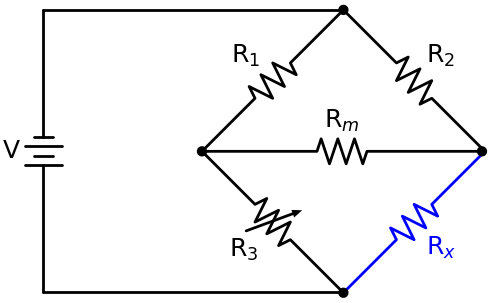

In [82]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)


    v1 = elm.SourceV().up().label('V', loc='top').length(5.65)
    l1 = elm.Line().right().length(6)
    d1 = elm.Dot()
    d.push()
    r1 = elm.Resistor().label('R$_1$', loc='top').theta(-135)
    r3 = elm.ResistorVar().label('R$_3$', loc='bot', ofst=[0, .25]).theta(-45)
    d.pop()
    r2 = elm.Resistor().label('R$_2$', loc='top').theta(-45)
    r4 = elm.Resistor().label('R$_x$', loc='bot').theta(-135).color('blue')
    d2 = elm.Dot()
    l2 = elm.Line().right().length(6).at(v1.start)
    
    d3 = elm.Dot().at(r1.end)
    r2 = elm.Resistor().label('R$_m$', loc='top').length(5.6)
    d4 = elm.Dot().at(amp.end)
    #d.save(next_name("./"), dpi=600, transparent=True)

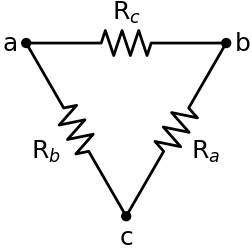

In [13]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)

    d1 = elm.Dot().label('a', loc='left')
    d.push()
    r3 = elm.Resistor().label('R$_c$', loc='top').right()
    d2 = elm.Dot().label('b', loc='right')
    r1 = elm.Resistor().label('R$_a$', loc='bot').theta(-120)
    d3 = elm.Dot().label('c', loc='bot')
    d.pop()
    r2 = elm.Resistor().label('R$_b$', loc='bot').theta(-60)
    #d.save(next_name("./"), dpi=600, transparent=True)

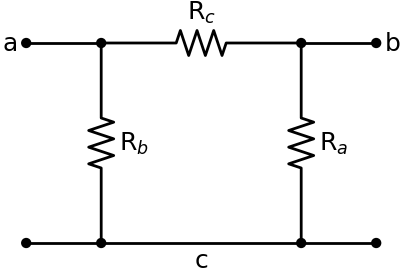

In [21]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)

    d1 = elm.Dot().label('a', loc='left')
    l1 = elm.Line().right().length(1.5)
    d.push()
    d2 = elm.Dot()
    r2 = elm.Resistor().label('R$_b$', loc='bot').down()
    d3 = elm.Dot()
    d.pop()
    r3 = elm.Resistor().label('R$_c$', loc='top').right()
    d4 = elm.Dot()
    d.push()
    l2 = elm.Line().right().length(1.5)
    d5 = elm.Dot().label('b', loc='right')
    d.pop()
    r1 = elm.Resistor().label('R$_a$', loc='bot').down()
    d6 = elm.Dot()
    d.push()
    l3 = elm.Line().right().length(1.5)
    d7 = elm.Dot()
    d.pop()
    l3 = elm.Line().left().label('c', loc='bot')
    l3 = elm.Line().left().length(1.5)
    d8 = elm.Dot()
    #d.save(next_name("./"), dpi=600, transparent=True)

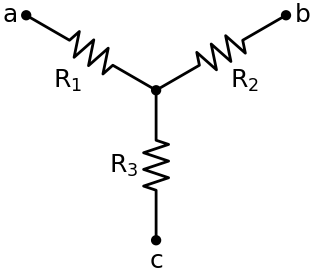

In [35]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)

    d1 = elm.Dot().label('a', loc='left')
    r1 = elm.Resistor().label('R$_1$', loc='bot').theta(-30)
    d2 = elm.Dot()
    d.push()
    r2 = elm.Resistor().label('R$_2$', loc='bot').theta(30)
    d3 = elm.Dot().label('b', loc='right')
    d.pop()
    r3 = elm.Resistor().label('R$_3$', loc='top').down()
    d4 = elm.Dot().label('c', loc='bot')
    #d.save(next_name("./"), dpi=600, transparent=True)

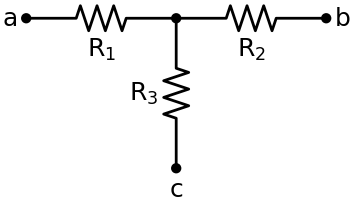

In [40]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)

    d1 = elm.Dot().label('a', loc='left')
    r1 = elm.Resistor().label('R$_1$', loc='bot').right()
    d2 = elm.Dot()
    d.push()
    r2 = elm.Resistor().label('R$_2$', loc='bot').right()
    d3 = elm.Dot().label('b', loc='right')
    d.pop()
    r3 = elm.Resistor().label('R$_3$', loc='top').down()
    d4 = elm.Dot().label('c', loc='bot')
    #d.save(next_name("./"), dpi=600, transparent=True)

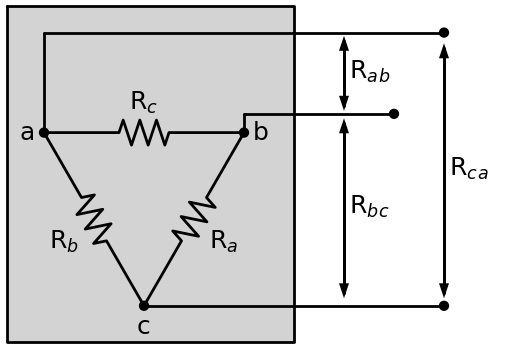

In [142]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)

    d1 = elm.Dot().label('a', loc='left')
    d.push()
    r3 = elm.Resistor().label('R$_c$', loc='top').right()
    d2 = elm.Dot().label('b', loc='right')
    r1 = elm.Resistor().label('R$_a$', loc='bot').theta(-120)
    d3 = elm.Dot().label('c', loc='bot')
    d.pop()
    r2 = elm.Resistor().label('R$_b$', loc='bot').theta(-60)

    l1 = elm.Line().at(d1.start).up().length(2)
    l2 = elm.Line().right().length(8)
    d4 = elm.Dot()

    l3 = elm.Line().at(d2.start).up().length(.375)
    l4 = elm.Line().right().length(3)
    d5 = elm.Dot()
    
    l5 = elm.Line().at(d3.start).right().length(6)
    d6 = elm.Dot()

    rect = elm.Rect(corner1=(d1.start[0]-2.75, d1.start[1]+6), corner2=(d3.end[0]+1, d3.end[1]+2.75), fill='lightgrey').at(d3.start).theta(0)
    A1 = elm.CurrentLabel(top=True, ofst=-1, length=3.5, reverse=False).at((l5.center[0], l5.center[1]+2)).label('R$_b$$_c$', loc='bot').theta(90)
    A1 = elm.CurrentLabel(top=True, ofst=-1, length=3.5, reverse=True).at((l5.center[0], l5.center[1]+1.9)).theta(90)

    A2 = elm.CurrentLabel(top=True, ofst=-1, length=1.4, reverse=False).at((l5.center[0], l5.center[1]+4.7)).label('R$_a$$_b$', loc='bot').theta(90)
    A2 = elm.CurrentLabel(top=True, ofst=-1, length=1.4, reverse=True).at((l5.center[0], l5.center[1]+4.6)).theta(90)

    A3 = elm.CurrentLabel(top=True, ofst=-1, length=5, reverse=False).at((l5.center[0]+2, l5.center[1]+2.75)).label('R$_c$$_a$', loc='bot').theta(90)
    A3 = elm.CurrentLabel(top=True, ofst=-1, length=5, reverse=True).at((l5.center[0]+2, l5.center[1]+2.65)).theta(90)


    #d.save(next_name("./"), dpi=600, transparent=True)

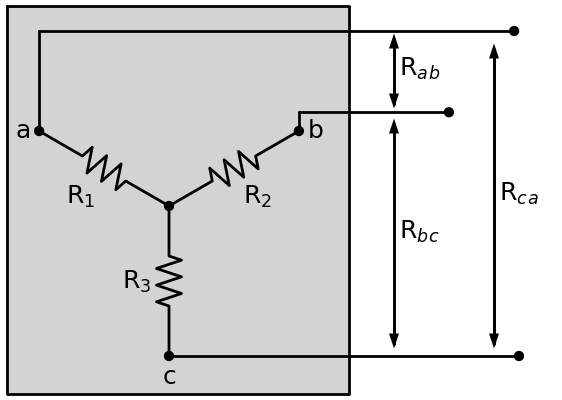

In [191]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)

    d1 = elm.Dot().label('a', loc='left')
    r1 = elm.Resistor().label('R$_1$', loc='bot').theta(-30)
    d2 = elm.Dot()
    d.push()
    r2 = elm.Resistor().label('R$_2$', loc='bot').theta(30)
    d3 = elm.Dot().label('b', loc='right')
    d.pop()
    r3 = elm.Resistor().label('R$_3$', loc='top').down()
    d4 = elm.Dot().label('c', loc='bot')

    l1 = elm.Line().at(d1.start).up().length(2)
    l2 = elm.Line().right().length(9.5)
    d5 = elm.Dot()

    l3 = elm.Line().at(d3.start).up().length(.375)
    l4 = elm.Line().right().length(3)
    d6 = elm.Dot()
    
    l5 = elm.Line().at(d4.start).right().length(7)
    d7 = elm.Dot()

    rect = elm.Rect(corner1=(d1.start[0]-3.25, d1.start[1]+7), corner2=(d4.end[0]+1, d4.end[1]+3.75), fill='lightgrey').at(d4.start).theta(0)


    A1 = elm.CurrentLabel(top=True, ofst=-1, length=4.5, reverse=False).at((l5.center[0], l5.center[1]+2.5)).label('R$_b$$_c$', loc='bot').theta(90)
    A1 = elm.CurrentLabel(top=True, ofst=-1, length=4.5, reverse=True).at((l5.center[0], l5.center[1]+2.4)).theta(90)

    A2 = elm.CurrentLabel(top=True, ofst=-1, length=1.4, reverse=False).at((l5.center[0], l5.center[1]+5.75)).label('R$_a$$_b$', loc='bot').theta(90)
    A2 = elm.CurrentLabel(top=True, ofst=-1, length=1.4, reverse=True).at((l5.center[0], l5.center[1]+5.65)).theta(90)

    A3 = elm.CurrentLabel(top=True, ofst=-1, length=6, reverse=False).at((l5.center[0]+2, l5.center[1]+3.25)).label('R$_c$$_a$', loc='bot').theta(90)
    A3 = elm.CurrentLabel(top=True, ofst=-1, length=6, reverse=True).at((l5.center[0]+2, l5.center[1]+3.15)).theta(90)

    #d.save(next_name("./"), dpi=600, transparent=True)

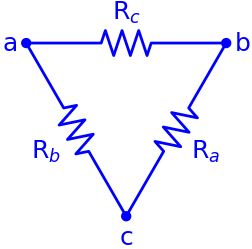

In [193]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18, color='blue')

    d1 = elm.Dot().label('a', loc='left')
    d.push()
    r3 = elm.Resistor().label('R$_c$', loc='top').right()
    d2 = elm.Dot().label('b', loc='right')
    r1 = elm.Resistor().label('R$_a$', loc='bot').theta(-120)
    d3 = elm.Dot().label('c', loc='bot')
    d.pop()
    r2 = elm.Resistor().label('R$_b$', loc='bot').theta(-60)
    #d.save(next_name("./"), dpi=600, transparent=True)

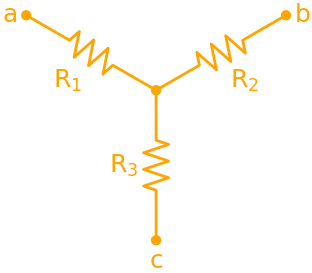

In [195]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18, color='orange')

    d1 = elm.Dot().label('a', loc='left')
    r1 = elm.Resistor().label('R$_1$', loc='bot').theta(-30)
    d2 = elm.Dot()
    d.push()
    r2 = elm.Resistor().label('R$_2$', loc='bot').theta(30)
    d3 = elm.Dot().label('b', loc='right')
    d.pop()
    r3 = elm.Resistor().label('R$_3$', loc='top').down()
    d4 = elm.Dot().label('c', loc='bot')
    #d.save(next_name("./"), dpi=600, transparent=True)

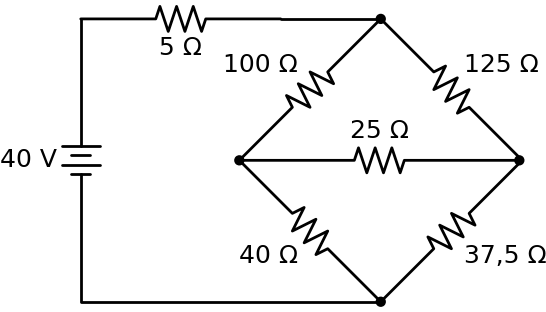

In [224]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)


    v1 = elm.Battery().up().label('40 V', loc='top').length(5.65).reverse()
    r6 = elm.Resistor().label('5 Ω', loc='bot').right().length(4)
    l1 = elm.Line().right().length(2)
    d1 = elm.Dot()
    d.push()
    r1 = elm.Resistor().label('100 Ω', loc='top').theta(-135)
    r3 = elm.Resistor().label('40 Ω', loc='bot').theta(-45)
    d.pop()
    r2 = elm.Resistor().label('125 Ω', loc='top').theta(-45)
    r4 = elm.Resistor().label('37,5 Ω', loc='bot').theta(-135)
    d2 = elm.Dot()
    l2 = elm.Line().left().tox(v1.start)
    
    d3 = elm.Dot().at(r1.end)
    r5 = elm.Resistor().label('25 Ω', loc='top').right().length(5.6)
    d4 = elm.Dot().at(amp.end)
    #d.save(next_name("./"), dpi=600, transparent=True)

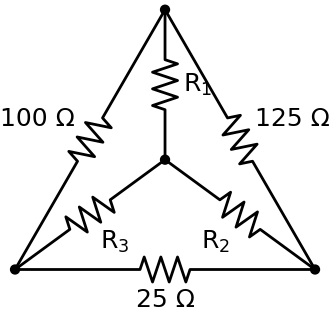

In [255]:
with schemdraw.Drawing() as d:
    d.config(unit=6, fontsize=18)

    d1 = elm.Dot()
    d.push()
    r3 = elm.Resistor().label('100 Ω', loc='top').theta(60)
    d2 = elm.Dot()
    d.push()
    ra = elm.Resistor().down().label('R$_1$', loc='bot').length(3)
    d4 = elm.Dot()
    rb = elm.Resistor().down().label('R$_3$', loc='bot').endpoints(ra.end, d1.start)
    rb = elm.Resistor().down().label('R$_2$', loc='bot').endpoints(ra.end, d3.start)
    d.pop()
    d.pop()
    r1 = elm.Resistor().label('25 Ω', loc='bot').theta(0)
    d3 = elm.Dot()
    r2 = elm.Resistor().label('125 Ω', loc='top').theta(120)
    #d.save(next_name("./"), dpi=600, transparent=True)

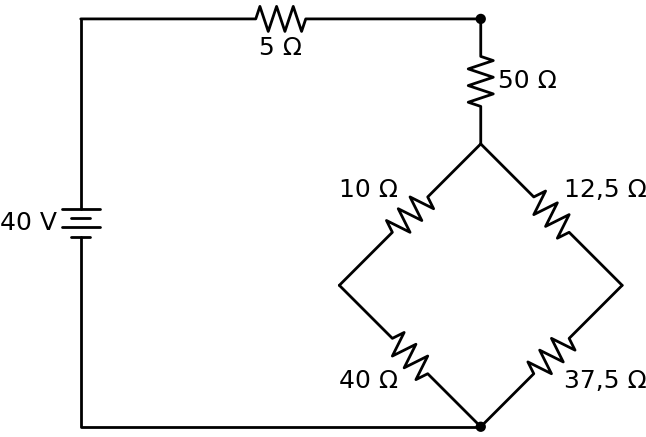

In [276]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)


    v1 = elm.Battery().up().label('40 V', loc='top').length(5.65+2.5).reverse()
    r6 = elm.Resistor().label('5 Ω', loc='bot').right().length(8)
    d1 = elm.Dot()
    r7 = elm.Resistor().label('50 Ω', loc='bot').down().length(2.5)
    
    d.push()
    r1 = elm.Resistor().label('10 Ω', loc='top').theta(-135)
    r3 = elm.Resistor().label('40 Ω', loc='bot').theta(-45)
    d.pop()
    r2 = elm.Resistor().label('12,5 Ω', loc='top').theta(-45)
    r4 = elm.Resistor().label('37,5 Ω', loc='bot').theta(-135)
    d2 = elm.Dot()
    l2 = elm.Line().left().tox(v1.start)
    
    #d.save(next_name("./"), dpi=600, transparent=True)

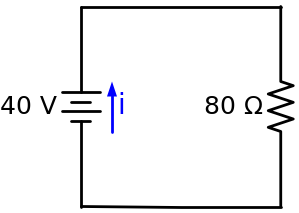

In [288]:
with schemdraw.Drawing() as d:
    d.config(unit=4, fontsize=18)


    v1 = elm.Battery().up().label('40 V', loc='top').reverse()
    l1 = elm.Line().right()
    r1 = elm.Resistor().down().label('80 Ω', loc='top')
    l1 = elm.Line().tox(v1.start)

    A1 = elm.CurrentLabel(top=False, ofst=.25, length=1, reverse=True).at(v1).label('i', loc='bot', fontsize=20).color('blue')

    
    #d.save(next_name("./"), dpi=600, transparent=True)